# **Setup**


To run this notebook, please proceed as follows:
- Use a Google Drive account and create a new folder called "Quantitative_Trading_and_Price_Impact_2026" in My Drive.
- Create a subfolder called "Data" and copy the two zip files "binSamples.zip" and "fillSamples.zip" into that subfolder.

To save changes in the notebook, go to File -> Save a copy in Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os
os.chdir("/content/drive/My Drive/Quantitative_Trading_and_Price_Impact_2026/")

Mounted at /content/drive


In [ ]:
import zipfile
import shutil
import sys
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
plt.style.use("ggplot")

In [ ]:
year = "2019"
data_dir = "/content/drive/My Drive/Quantitative_Trading_and_Price_Impact_2026/Data/"
bin_sample_path = f"{data_dir}binSamples/"
fill_sample_path = f"{data_dir}fillSamples/"
result_path = f"{data_dir}inter_results/"
os.makedirs(result_path, exist_ok=True)

In [ ]:
path_to_zip_file = f"{data_dir}binSamples.zip"
with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

In [ ]:
path_to_zip_file = f"{data_dir}fillSamples.zip"
with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

# **Exercise Set 1 (26 Feb 2026)**

### **Computing volume curves**

In [ ]:
year = "2019"
month_int = 1
month = '%02d' % month_int
filename = "bin%s%s.csv" % (year, month)
bin_sample_df = pd.read_csv(bin_sample_path+filename)

traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns="time", values="trade").fillna(0)
unsigned_traded_volume_df = traded_volume_df.abs().reset_index()
monthly_volume_curve_df = unsigned_traded_volume_df.drop(columns="date").groupby("stock").mean()
monthly_volume_curve_df.iloc[:,:] = monthly_volume_curve_df.values[:,::-1].cumsum(axis=1)[:,::-1]


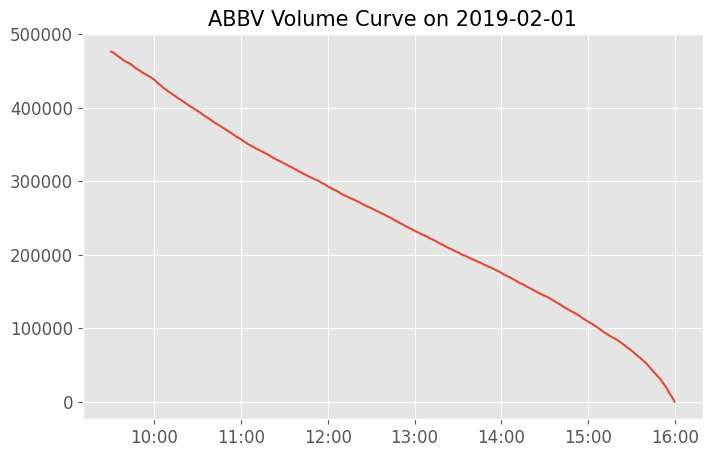

In [ ]:
stock = "ABBV"
fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(pd.to_datetime(monthly_volume_curve_df.loc[stock].index, format='%H:%M:%S'), monthly_volume_curve_df.loc[stock].values)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.yaxis.get_offset_text().set_fontsize(12)
ax.set_title(f"{stock} Volume Curve on 2019-02-01", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
plt.show()

### **Computing VWAP schedules**

In [ ]:
year = "2019"
traded_volume_dfs=[]
for month_int in range(1, 3):
  month = '%02d' % month_int
  filename = "bin%s%s.csv" % (year, month)
  bin_sample_df = pd.read_csv(bin_sample_path+filename)
  traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns="time", values="trade").fillna(0)
  traded_volume_dfs.append(traded_volume_df)
  print(f"Month {month} complete")
traded_volume_df = pd.concat(traded_volume_dfs, axis=0)

Month 01 complete
Month 02 complete


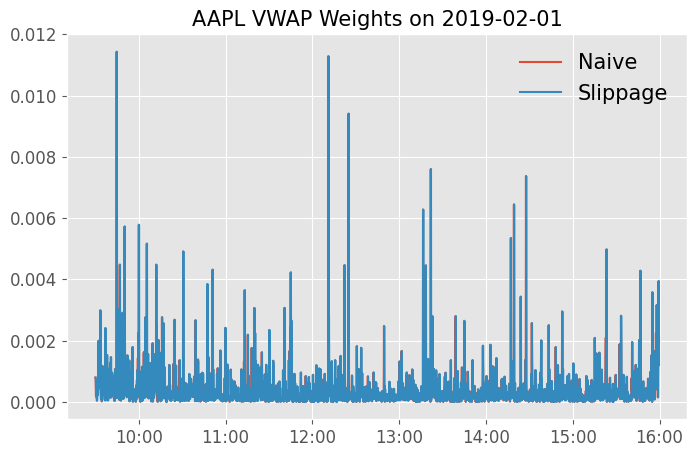

In [ ]:
stock = 'AAPL'
date = '2019-02-01'
fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(pd.to_datetime(traded_volume_df.loc[stock, date].index[:-2], format='%H:%M:%S'), traded_volume_df.loc[stock, date].abs()[:-2] / traded_volume_df.loc[stock, date].abs().sum(), label="Naive")
ax.plot(pd.to_datetime(traded_volume_df.loc[stock, date].index[:-2], format='%H:%M:%S'), traded_volume_df.loc[stock, date].abs().shift(1)[:-2] / traded_volume_df.loc[stock, date].abs().sum(), label="Slippage")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.yaxis.get_offset_text().set_fontsize(12)
ax.set_title(f"{stock} VWAP Weights on {date}", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
ax.legend(fontsize=15, frameon=False)
plt.show()

We start from
$$
q_t^{\text{realistic}} = \min\Big\{ \frac{|v_{t-\delta t}|}{V_t} ,1 \Big\} \Big(Q - \sum_{s<t} q_s^{\text{realistic}}\Big).
$$
Let $\alpha_t=\min\Big\{ \frac{|v_{t-\delta t}|}{V_t} ,1 \Big\}$ and $R_t=1-\sum_{s<t}q_s^{\text{realistic}}$, so that
$$q_t^{\text{realistic}}=\alpha_tR_t.$$
Here $R_t$ represents the remaining volume to be traded before bin $t$. It can be written recursively as
$$
R_{t+1}=R_t-q_t=R_t(1-\alpha_t),
$$
and thus since $R_1=1$,
$$
R_t=\prod_{i=1}^{t-1}(1-\alpha_t).
$$
Therefore, it follows that
$$
q_t^{\text{realistic}}=\alpha_tR_t=R_t-R_t(1-\alpha_t)=R_t-R_{t+1}.
$$

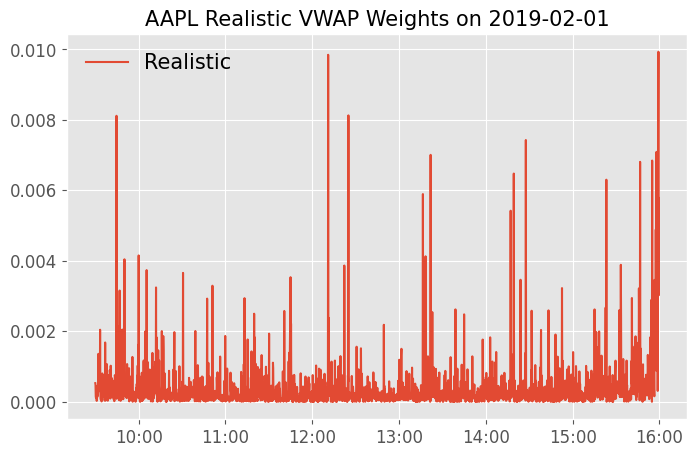

In [ ]:
#Compute realisic VWAP according to above formulas with Q=1 (traded_volume_df index: stock,date; monthly_volume_curve_df index: stock)
cum_weights = (1 - np.minimum(traded_volume_df.abs()[:-2] / monthly_volume_curve_df[:-2], 1)).cumprod(axis=1).shift(1, axis=1)
cum_weights.iloc[:, 0] = 1.0
vwap_weights = cum_weights.diff(-1, axis=1)

fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(pd.to_datetime(traded_volume_df.loc[stock, date].index[:-2], format='%H:%M:%S'), vwap_weights.loc[stock, date][:-2], label="Realistic")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.yaxis.get_offset_text().set_fontsize(12)
ax.set_title(f"{stock} Realistic VWAP Weights on {date}", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
ax.legend(fontsize=15, frameon=False)
plt.show()

### **Creating synthetic alphas**

We add noise to the realized alpha to create a synthetic alpha
$$
\alpha_t^h = \frac{x \cdot (P_{t+h} - P_t) + y \cdot (W_{t+h} - W_t)}{P_t} = x r_t^h + \frac{y \cdot (W_{t+h} - W_t)}{P_t}.
$$
Here $P$ is the observed midprice and $W$ an independent Brownian motion to add noise.

Example application:
Backtest a trading algorithm for different alphas to compute
- sensitivity to alpha size,
- sensitivity to alpha correlation with returns,
- confidence intervals on P&L.

1. By definition of $\alpha_t^h$, we have
$$
    \alpha_t^h = x r_t^h + \frac{y(W_{t+h} - W_t)}{P_t}.
$$
Therefore, its variance is given by
$$
    Var(\alpha_t^h) = x^2 Var(r_t^h) + y^2 \mathbb{E}[P_t^{-2}] h.
$$
Next, the covariance of $\alpha_t^h$ and $r_t^h$ is
$$
    Cov(\alpha_t^h, r_t^h) = x Var(r_t^h).
$$
Therefore, we get that
$$
    Corr(\alpha_t^h, r_t^h) = \frac{Cov(\alpha_t^h, r_t^h)}{\sqrt{Var(\alpha_t^h) Var(r_t^h)}} = \frac{x \sqrt{Var(r_t^h)}}{\sqrt{(x^2 Var(r_t^h) + y^2 \mathbb{E}[P_t^{-2}] h)}}.
$$

2. We want to guarantee that
$$
    \frac{x \sqrt{Var(r_t^h)}}{\sqrt{(x^2 Var(r_t^h) + y^2 \mathbb{E}[\frac{1}{P_t^2}] h)}} = \rho,\quad\text{and}\quad
    \mathbb{E}\left[ r_t^h | \alpha_t^h \right] = \alpha_t^h.
$$
Here the second condition essentially ensures that the synthetic alpha is an unbiased predictor of the realized alpha. When two random variables  $A$  and  $B$  are jointly normal, their conditional expectation is given by:
$$
\mathbb{E}[ B | A ] = A\frac{\text{Cov}(A, B)}{\text{Var}(A)}
$$
It follows that
$$
\mathbb{E}\left[ r_t^h | \alpha_t^h \right] = \alpha_t^h \frac{x \text{Var}(r_t^h)}{x^2 \text{Var}(r_t^h) + y^2 \mathbb{E}[P_t^{-2}] h}=  \alpha_t^h\rho \frac{\sqrt{Var(r_t^h)}}{\sqrt{x^2 Var(r_t^h) + y^2 \mathbb{E}[\frac{1}{P_t^2}] h}}.
$$
Thus, we need to achieve
$$
    \rho \alpha_t^h \frac{\sqrt{Var(r_t^h)}}{\sqrt{x^2 Var(r_t^h) + y^2 \mathbb{E}[\frac{1}{P_t^2}] h}} = \alpha_t^h
$$
and the correlation constraint. This is equivalent to the two equations
\begin{align}
    \rho \frac{\sqrt{Var(r_t^h)}}{\sqrt{x^2 Var(r_t^h) + y^2 \mathbb{E}[\frac{1}{P_t^2}] h}} = 1,\\
    x \frac{\sqrt{Var(r_t^h)}}{\sqrt{(x^2 Var(r_t^h) + y^2 \mathbb{E}[\frac{1}{P_t^2}] h)}} = \rho,
\end{align}
which are solved by
\begin{align}
    x = \rho^2 \quad\text{and}\quad
    y = \rho \sqrt{1 - \rho^2} \sqrt{\frac{Var(r_t^h)}{\mathbb{E}[\frac{1}{P_t^2}] h}}.
\end{align}

In [ ]:
year = "2019"
month_int = 2
month = '%02d' % month_int
filename = "bin%s%s.csv" % (year, month)
bin_sample_df = pd.read_csv(bin_sample_path+filename)

In [ ]:
px_df = bin_sample_df[["stock", "date", "midEnd", "time"]].pivot(index=["stock", "date"], columns="time", values="midEnd").ffill(axis="columns").bfill(axis="columns")
returns = px_df.pct_change(1, axis="columns").ffill(axis="columns").bfill(axis="columns")
returns = returns.unstack()
variance_returns = returns.T.var()
mean_inverse_prices= (px_df ** (-2)).groupby(level="stock").mean().T.mean()

In [ ]:
stock="AAPL"
required_corr = 0.9
stock_px_df = px_df.loc[stock]
x = required_corr ** 2
y = required_corr * np.sqrt(1 - required_corr ** 2) * np.sqrt(variance_returns[stock] / mean_inverse_prices[stock])
print(f"Variance of realized alpha: {variance_returns[stock]}")
print(f"(x,y)=({x},{y})")

Variance of realized alpha: 4.400194041141323e-08
(x,y)=(0.81,0.014132609700109445)


In [ ]:
np.random.seed(1)
px_changes = stock_px_df.T.diff(1, axis=0).iloc[1:,:]
W_diffs = np.random.normal(loc=0, scale=1.0, size=(stock_px_df.shape[0], stock_px_df.shape[1]-1))
Ws = np.concatenate([np.zeros((W_diffs.shape[0], 1)), W_diffs.cumsum(axis=1)], axis=1).T
W_h_diffs = Ws[1:,:] - Ws[:-1,:]
px_changes = px_changes * x + W_h_diffs * y
synthetic_returns = (px_changes / (stock_px_df.T.shift(1, axis=0)))
synthetic_returns.index.name = "time"
returns_df = pd.DataFrame({
    "actual" : returns.loc[stock],
     "synthetic" : synthetic_returns.stack(),
})
correlation = returns_df.corr().iloc[0,1]
actual_variance = returns_df["actual"].var()
synthetic_variance = returns_df["synthetic"].var()
synthetic_alpha_diffs = returns_df.drop("actual", axis="columns").unstack("time")["synthetic"]
synthetic_alphas = synthetic_alpha_diffs.cumsum(axis="columns")
print(f"Variance of synthetic alpha: {synthetic_variance}")
print(f"Correlation with the realized alpha: {correlation}")

Variance of synthetic alpha: 3.527143638487322e-08
Correlation with the realized alpha: 0.8989728428678765


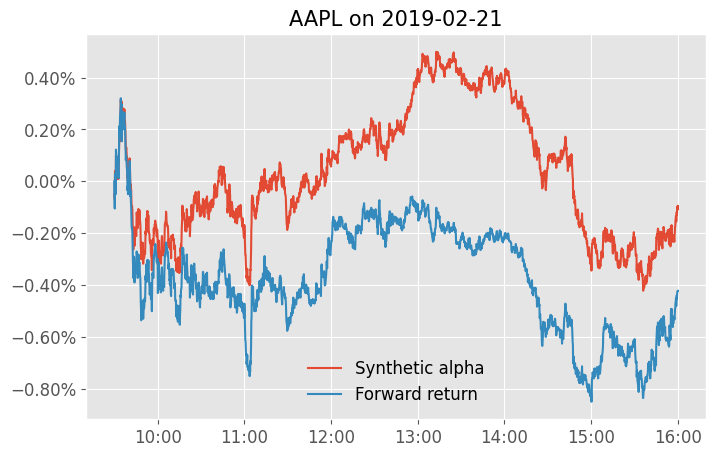

In [ ]:
date = "2019-02-21"

fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(pd.to_datetime(stock_px_df.columns, format='%H:%M:%S'), synthetic_alphas.loc[date].values, label="Synthetic alpha")
ax.plot(pd.to_datetime(stock_px_df.columns, format='%H:%M:%S'), stock_px_df.loc[date] / stock_px_df.loc[date].iloc[0] - 1, label="Forward return")
ax.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title(f"{stock} on {date}", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
ax.legend(fontsize=12, frameon=False)
plt.show()

# **Exercise Set 2 (05 Mar 2026)**

### **Computing price volatility and ADV**

In [ ]:
monthly_stock_info_dfs = []
for month_int in range(1, 13):
    sys.stdout.write(f"\rCurrent month being processed: {month_int}")
    sys.stdout.flush()
    month = '%02d' % month_int
    filename = "bin%s%s.csv" % (year, month)
    bin_sample_df = pd.read_csv(bin_sample_path+filename)

    monthly_traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns=["time"])["trade"].fillna(0).astype(int)
    monthly_px_df = bin_sample_df[["stock", "date", "midEnd", "time"]].pivot(index=["stock", "date"], columns=["time"])["midEnd"].ffill(axis="columns").bfill(axis="columns")
    monthly_stock_info_dfs.append(pd.DataFrame({
        "px_vol" : monthly_px_df.pct_change(1, axis="columns").std(axis="columns"),
        "volume" : monthly_traded_volume_df.abs().sum(axis="columns"),
    }).reset_index())

stock_info_df = pd.concat(monthly_stock_info_dfs).reset_index(drop=True)

Current month being processed: 12

In [ ]:
stock_info_df

,stock,date,px_vol,volume
0,A,2019-01-02,0.000383,217804
1,A,2019-01-03,0.000527,485020
2,A,2019-01-04,0.000366,244093
3,A,2019-01-07,0.000359,251175
4,A,2019-01-08,0.000364,181329
...,...,...,...,...
12397,ARE,2019-12-20,0.000225,57796
12398,ARE,2019-12-23,0.000112,45866
12399,ARE,2019-12-24,0.000135,17555
12400,ARE,2019-12-26,0.000138,24736


In [ ]:
#Save the data for later use
filename = f"volume_px_vol_{year}.csv"
stock_info_df.to_csv(result_path+filename, index=False)

In [ ]:
num_days_precompute = 20
stacked_info = stock_info_df.pivot(index="date", columns="stock", values=["px_vol", "volume"]).rolling(num_days_precompute).mean().shift(1)
scaling_df = pd.DataFrame({
    "px_vol" : stacked_info["px_vol"].unstack(),
    "volume" : stacked_info["volume"].unstack(),
}).reset_index()
#Save the data for later use
filename = f"scaling_factors_{year}.csv"
scaling_df.to_csv(result_path+filename, index=False)

In [ ]:
scaling_df[:30]

,stock,date,px_vol,volume
0,A,2019-01-02,NaN,NaN
1,A,2019-01-03,NaN,NaN
2,A,2019-01-04,NaN,NaN
3,A,2019-01-07,NaN,NaN
4,A,2019-01-08,NaN,NaN
5,A,2019-01-09,NaN,NaN
6,A,2019-01-10,NaN,NaN
7,A,2019-01-11,NaN,NaN
8,A,2019-01-14,NaN,NaN
9,A,2019-01-15,NaN,NaN


### **Computing intraday impact states**

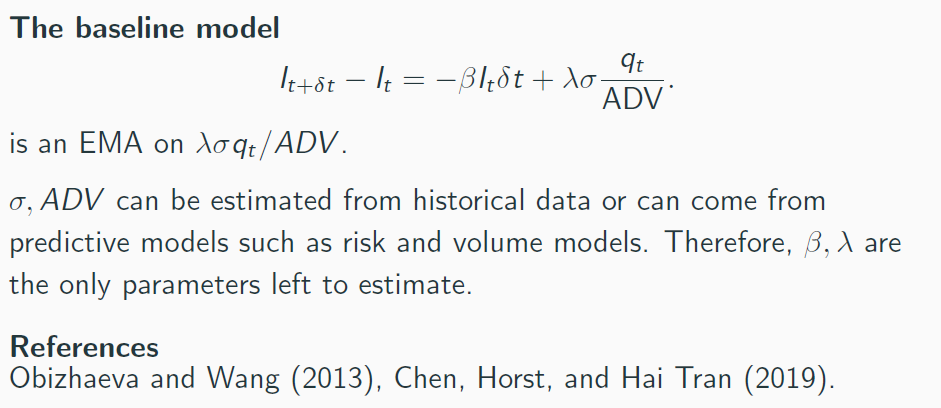

Setting $\delta t=1$ and rewriting the equation yields
$$
\frac{I_{t+1}}{\lambda}=(1-\beta)\frac{I_t}{\lambda}+\sigma\frac{q_t}{ADV},
$$
which in turn allows the iterative computation of $I_t/\lambda$ for $t=0,1,2,\ldots$.

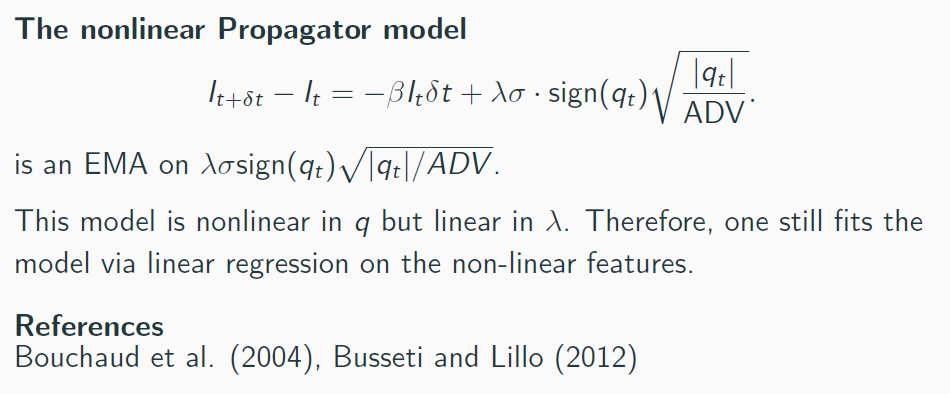

Setting $\delta t=1$ and rewriting the equation yields
$$
\frac{I_{t+1}}{\lambda}=(1-\beta)\frac{I_t}{\lambda}+\sigma\operatorname{sgn}(q_t)\sqrt{\frac{|q_t|}{ADV}},
$$
which in turn allows the iterative computation of $I_t/\lambda$ for $t=0,1,2,\ldots$.

In [ ]:
month_int = 2
month = '%02d' % month_int
filename = "bin%s%s.csv" % (year, month)
bin_sample_df = pd.read_csv(bin_sample_path+filename)

traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns=["time"])["trade"].fillna(0).astype(int)
px_df = bin_sample_df[["stock", "date", "midEnd", "time"]].pivot(index=["stock", "date"], columns=["time"])["midEnd"].ffill(axis="columns").bfill(axis="columns")

In [ ]:
stock="AAPL"
date="2019-02-21"

traded_volume_df.loc[stock,date]

,AAPL
,2019-02-21
time,
09:30:00,-4686
09:30:10,-2508
09:30:20,-37
09:30:30,-1515
09:30:40,-907
...,...
15:59:20,911
15:59:30,250


In [ ]:
def impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type):

    space_kernels = {
        "linear" : lambda x : x,
        "sqrt" : lambda x : np.sign(x) * np.sqrt(np.abs(x)),
    }

    beta = np.log(2) / (half_life / 10)
    decay_factor = np.exp(-beta)
    pre_ewm = traded_volume_df.copy()
    pre_ewm = pre_ewm.divide(monthly_scaling_factor["volume"], axis="rows")
    pre_ewm = space_kernels[model_type](pre_ewm)
    pre_ewm = pre_ewm.multiply(monthly_scaling_factor["px_vol"], axis="rows")
    pre_ewm.iloc[:, 1:] /= (1 - decay_factor)
    cum_impact = cum_impact = pre_ewm.T.ewm(alpha=1-decay_factor, adjust=False).mean().T
    return cum_impact

In [ ]:
monthly_scaling_factor = scaling_df.set_index(["stock", "date"]).loc[traded_volume_df.index]
half_life = 3600
model_type = "linear"
cum_impact = impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type)


In [ ]:
cum_impact.loc[stock,date]

,AAPL
,2019-02-21
time,
09:30:00,-4.830680e-07
09:30:10,-7.406822e-07
09:30:20,-7.430717e-07
09:30:30,-8.978199e-07
09:30:40,-9.895933e-07
...,...
15:59:20,-3.517321e-06
15:59:30,-3.484783e-06


### **Decomposing VWAP slippage (PnL attribution)**

The impact slippage is defined as
$$
\int_0^T (I_t - I_0) dQ_t,
$$
where $I$ is the fitted impact caused by the order $Q$.
Similarly, the alpha slippage is defined as
$$
\int_0^T \frac{P_t - P_0}{P_0} dQ_t.
$$

By decomposing total slippage into impact slippage and alpha slippage, traders can attribute the loss (or cost) more precisely:
- The impact slippage quantifies the nonnegative unavoidable cost of moving the market with your own orders.
- The alpha slippage captures the price movement due to market conditions that can be interpreted as the market's "alpha" (which might be favorable or unfavorable).

In [ ]:
impact_slippage = (cum_impact * traded_volume_df.shift(1, axis="columns")).sum(axis="columns")
impact_slippage

stock  date      
A      2019-02-01    0.299242
       2019-02-04    0.266261
       2019-02-05    0.161289
       2019-02-06    0.892485
       2019-02-07    0.137259
                       ...   
ARE    2019-02-22    0.123580
       2019-02-25    0.060190
       2019-02-26    0.395443
       2019-02-27    0.365931
       2019-02-28    0.265569
Length: 950, dtype: float64

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1382/1848117041.py:3: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title("Impact Slippage Histogram ($\lambda=1$)")


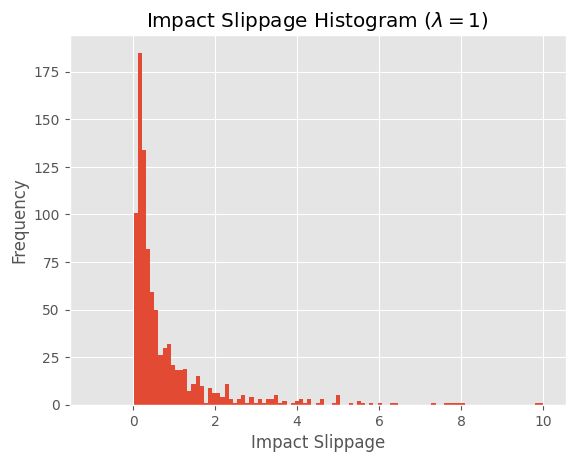

In [ ]:
bins = np.linspace(-1, 10, 110)
ax = impact_slippage.hist(bins=bins)
ax.set_title("Impact Slippage Histogram ($\lambda=1$)")
ax.set_xlabel("Impact Slippage")
ax.set_ylabel("Frequency")
plt.show()

In [ ]:
returns = px_df.divide(px_df.iloc[:,0], axis="rows") - 1
alpha_slippage = (returns * traded_volume_df.shift(1, axis="columns")).sum(axis="columns")

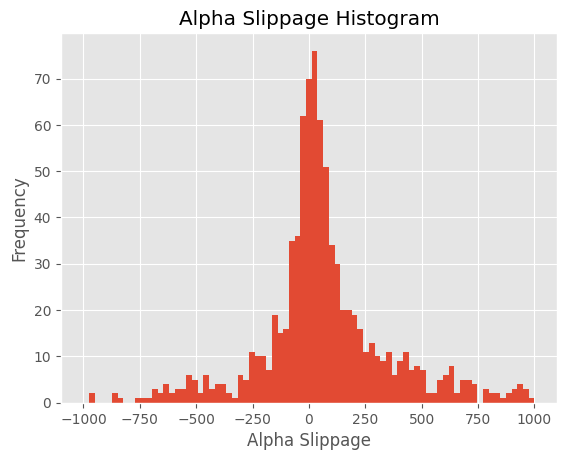

In [ ]:
bins = np.linspace(-1000, 1000, 80)
ax=alpha_slippage.hist(bins=bins)
ax.set_title("Alpha Slippage Histogram")
ax.set_xlabel("Alpha Slippage")
ax.set_ylabel("Frequency")
plt.show()

# **Exercise Set 3 (12 Mar 2026)**

###**Fitting price impact models**

In [ ]:
#Load traded volume and prices as before
year = "2019"
traded_volume_dfs=[]
px_dfs=[]
for month_int in range(1, 13):
  sys.stdout.write(f"\rCurrent month being processed: {month_int}")
  sys.stdout.flush()
  month = '%02d' % month_int
  filename = "bin%s%s.csv" % (year, month)
  bin_sample_df = pd.read_csv(bin_sample_path+filename)
  traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns="time", values="trade").fillna(0)
  px_df = bin_sample_df[["stock", "date", "midEnd", "time"]].pivot(index=["stock", "date"], columns=["time"])["midEnd"].ffill(axis="columns").bfill(axis="columns")
  traded_volume_dfs.append(traded_volume_df)
  px_dfs.append(px_df)
traded_volume_df = pd.concat(traded_volume_dfs, axis=0)
px_df=pd.concat(px_dfs, axis=0)

Current month being processed: 12

In [ ]:
#Recover scaling factors (see Exercise 2a)
filename = f"volume_px_vol_{year}.csv"
scaling_df=pd.read_csv(result_path+filename)

In [ ]:
#Redefine the impact state function (see Exercise 2b)
def impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type):

    space_kernels = {
        "linear" : lambda x : x,
        "sqrt" : lambda x : np.sign(x) * np.sqrt(np.abs(x)),
    }

    beta = np.log(2) / (half_life / 10)
    decay_factor = np.exp(-beta)
    pre_ewm = traded_volume_df.copy()
    pre_ewm = pre_ewm.divide(monthly_scaling_factor["volume"], axis="rows")
    pre_ewm = space_kernels[model_type](pre_ewm)
    pre_ewm = pre_ewm.multiply(monthly_scaling_factor["px_vol"], axis="rows")
    pre_ewm.iloc[:, 1:] /= (1 - decay_factor)
    cum_impact = cum_impact = pre_ewm.T.ewm(alpha=1-decay_factor, adjust=False).mean().T
    return cum_impact

In [ ]:
# Precompute regression statistics
# Here, explanation_horizon_periods are the number of 10s-periods for the explanation horizon (e.g. 5min corresponds to 30 periods)

def impact_regression_statistics(cum_impact, explanation_horizon_periods, px_df):
    impact_changes = cum_impact.diff(explanation_horizon_periods, axis="columns").T.unstack()
    reg_stat_df = impact_changes.reset_index().rename({"level_2":"time", 0:"x"}, axis="columns")
    returns = px_df.pct_change(explanation_horizon_periods, axis="columns").T.unstack().reset_index().rename({"level_2":"time", 0:"y"}, axis="columns")
    reg_stat_df = reg_stat_df.loc[reg_stat_df["time"] >= "10:00:00"].dropna(axis=0).copy()
    reg_stat_df["y"] = returns["y"]
    reg_stat_df["xy"] = reg_stat_df["x"] * reg_stat_df["y"]
    reg_stat_df["xx"] = reg_stat_df["x"] * reg_stat_df["x"]
    reg_stat_df["yy"] = reg_stat_df["y"] * reg_stat_df["y"]
    reg_stat_df["count"] = 1
    return reg_stat_df

In [ ]:
half_life = 3600 #half-life in seconds
explanation_horizon_periods = 6

beta = np.log(2) / half_life
decay_factor = np.exp(-beta * 10)
monthly_scaling_factor = scaling_df.set_index(["stock", "date"]).loc[traded_volume_df.index]

model_type = "linear"
cum_impact = impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type)
reg_stat_df = impact_regression_statistics(cum_impact, explanation_horizon_periods, px_df)
linear_summary_df = reg_stat_df.groupby(["stock", "date"]).sum().reset_index().drop(columns=["time"])
linear_summary_df = linear_summary_df.loc[linear_summary_df["y"] >= 0.0001].copy()
linear_summary_df["date"] = pd.to_datetime(linear_summary_df["date"])
filename = f"inter_results_{model_type}_{year}.csv"
linear_summary_df.to_csv(result_path+filename, index=False)

model_type = "sqrt"
cum_impact = impact_state(traded_volume_df, monthly_scaling_factor, half_life, model_type)
reg_stat_df = impact_regression_statistics(cum_impact, explanation_horizon_periods, px_df)
sqrt_summary_df = reg_stat_df.groupby(["stock", "date"]).sum().reset_index().drop(columns=["time"])
sqrt_summary_df = sqrt_summary_df.loc[sqrt_summary_df["y"] >= 0.0001].copy()
sqrt_summary_df["date"] = pd.to_datetime(sqrt_summary_df["date"])
filename = f"inter_results_{model_type}_{year}.csv"
sqrt_summary_df.to_csv(result_path+filename, index=False)


In [ ]:
linear_summary_df

,stock,date,x,y,xy,xx,yy,count
2,A,2019-01-04,-0.000029,0.049112,4.691245e-07,1.022926e-09,0.001220,2161
3,A,2019-01-07,-0.000038,0.091259,3.877372e-07,1.327259e-09,0.000915,2161
4,A,2019-01-08,0.000003,0.012770,3.438717e-07,1.422903e-09,0.001186,2161
6,A,2019-01-10,0.000002,0.102493,3.502556e-07,8.731926e-10,0.000723,2161
7,A,2019-01-11,0.000169,0.076132,3.441060e-07,1.645929e-09,0.000421,2161
...,...,...,...,...,...,...,...,...
12393,ARE,2019-12-16,-0.000044,0.018273,2.157081e-07,6.693285e-10,0.000399,2161
12395,ARE,2019-12-18,-0.000192,0.091778,1.249939e-07,8.303005e-10,0.000331,2161
12396,ARE,2019-12-19,0.000020,0.021569,1.475928e-07,5.044890e-10,0.000279,2161
12399,ARE,2019-12-24,0.000029,0.028445,1.765785e-07,1.069536e-09,0.000121,2161


In [ ]:
def regression_result(daily_stock_reg_info_df, in_sample_month):
    in_sample_df = daily_stock_reg_info_df.loc[daily_stock_reg_info_df["date"].dt.month == in_sample_month]
    out_sample_df = daily_stock_reg_info_df.loc[daily_stock_reg_info_df["date"].dt.month == in_sample_month + 1]
    in_sample_summary_df = in_sample_df.groupby("stock")[["xy", "xx", "yy", "x", "y", "count"]].sum()
    out_sample_summary_df = out_sample_df.groupby("stock")[["xy", "xx", "yy", "x", "y", "count"]].sum()
    in_sample_summary_df.columns = "is_" + in_sample_summary_df.columns
    out_sample_summary_df.columns = "oos_" + out_sample_summary_df.columns

    summary_df = pd.merge(in_sample_summary_df, out_sample_summary_df, left_index=True, right_index=True, how="inner")
    summary_df["beta_estimate"] = (summary_df["is_xy"] - summary_df["is_x"] * summary_df["is_y"] / summary_df["is_count"]) / (summary_df["is_xx"] - summary_df["is_x"] ** 2 / summary_df["is_count"])
    summary_df["alpha_estimate"] = summary_df["is_y"] / summary_df["is_count"] - summary_df["beta_estimate"] * summary_df["is_x"] / summary_df["is_count"]
    summary_df["is_sse"] = summary_df["is_yy"] - summary_df["is_y"] ** 2 / summary_df["is_count"]
    summary_df["is_mse"] = summary_df["is_yy"] - 2 * summary_df["beta_estimate"] * summary_df["is_xy"] - 2 * summary_df["alpha_estimate"] * summary_df["is_y"] + 2 * summary_df["alpha_estimate"] * summary_df["beta_estimate"] * summary_df["is_x"] + summary_df["beta_estimate"] ** 2 * summary_df["is_xx"] + summary_df["alpha_estimate"] ** 2 * summary_df["is_count"]
    summary_df["is_rsq"] = 1 - summary_df["is_mse"] / summary_df["is_sse"]
    summary_df["oos_sse"] = summary_df["oos_yy"] - summary_df["oos_y"] ** 2 / summary_df["oos_count"]
    summary_df["oos_mse"] = summary_df["oos_yy"] - 2 * summary_df["beta_estimate"] * summary_df["oos_xy"] - 2 * summary_df["alpha_estimate"] * summary_df["oos_y"] + 2 * summary_df["alpha_estimate"] * summary_df["beta_estimate"] * summary_df["oos_x"] + summary_df["beta_estimate"] ** 2 * summary_df["oos_xx"] + summary_df["alpha_estimate"] ** 2 * summary_df["oos_count"]
    summary_df["oos_rsq"] = 1 - summary_df["oos_mse"] / summary_df["oos_sse"]
    return summary_df

In [ ]:
in_sample_month = 2
linear_r2_df = regression_result(linear_summary_df, in_sample_month)
linear_r2_df = linear_r2_df[["beta_estimate", "alpha_estimate", "is_rsq", "oos_rsq"]].reset_index()
filename = f"regression_linear_{year}.csv"
linear_r2_df.to_csv(result_path+filename, index=False)

mean_is=linear_r2_df["is_rsq"].mean().round(5)
mean_oos=linear_r2_df["oos_rsq"].mean().round(5)
print(f"Linear model mean IS R^2 for Month {in_sample_month}: {mean_is}")
print(f"Linear model mean OOS R^2 for Months {in_sample_month}/{in_sample_month+1}: {mean_oos}")
linear_r2_df[:20]

Linear model mean IS R^2 for Month 2: 0.19496
Linear model mean OOS R^2 for Months 2/3: 0.17641


,stock,beta_estimate,alpha_estimate,is_rsq,oos_rsq
0,A,378.404834,0.000014,0.228820,0.170152
1,AAL,368.256126,0.000006,0.217600,0.223899
2,AAP,341.517628,0.000044,0.202212,0.203339
3,AAPL,434.193710,0.000013,0.255271,0.240373
4,ABBV,334.790507,0.000021,0.161713,0.175189
5,ABC,355.054352,0.000020,0.227198,0.220535
6,ABMD,214.666813,0.000033,0.196094,0.185611
7,ABT,406.256679,0.000014,0.172627,0.149527
8,ACN,378.163009,0.000010,0.179074,0.169670
9,ADBE,395.551594,0.000008,0.170157,0.124879


In [ ]:
in_sample_month = 2
sqrt_r2_df = regression_result(sqrt_summary_df, in_sample_month)
sqrt_r2_df = sqrt_r2_df[["beta_estimate", "alpha_estimate", "is_rsq", "oos_rsq"]].reset_index()
filename = f"regression_sqrt_{year}.csv"
sqrt_r2_df.to_csv(result_path+filename, index=False)

mean_is=sqrt_r2_df["is_rsq"].mean().round(5)
mean_oos=sqrt_r2_df["oos_rsq"].mean().round(5)
print(f"Square-root model mean IS R^2 for Month {in_sample_month}: {mean_is}")
print(f"Square-root model mean OOS R^2 for Months {in_sample_month}/{in_sample_month+1}: {mean_oos}")
sqrt_r2_df[:20]

Square-root model mean IS R^2 for Month 2: 0.28156
Square-root model mean OOS R^2 for Months 2/3: 0.27498


,stock,beta_estimate,alpha_estimate,is_rsq,oos_rsq
0,A,20.483747,0.000014,0.289058,0.297847
1,AAL,22.377698,0.000007,0.321603,0.372831
2,AAP,21.579321,0.000041,0.312330,0.290677
3,AAPL,23.683745,0.000018,0.365194,0.369502
4,ABBV,17.607503,0.000020,0.228856,0.233466
5,ABC,21.353677,0.000019,0.303433,0.287959
6,ABMD,19.970578,0.000026,0.282116,0.274876
7,ABT,19.290822,0.000015,0.213287,0.204164
8,ACN,18.984628,0.000010,0.215249,0.227925
9,ADBE,21.806356,0.000005,0.267854,0.242424


###**Computing markouts**

Markout is a measure used in execution analysis to capture the price move following a trade relative to the trade's price, adjusted for the direction of the trade. Specifically, for a fill at time $t$, the markout over a horizon h is defined as
$$
\tilde{\alpha}_t^h = \left( \frac{P_{t+h} - P_t}{P_t} \right)\text{sign}(v_t),$$
where:
- $P_t$ is the price at the time of the trade,
- $P_{t+h}$ is the price after the horizon $h$,
- $\text{sign}(v_t)$ ensures that the return is aligned with the direction of the trade (positive for buys, negative for sells).

The idea is that markout reflects the realized price performance after executing a trade. A positive markout indicates that, after a buy, the price increased (or after a sell, the price decreased), suggesting a favorable post-trade move, whereas a negative markout would imply adverse price movement.

In [ ]:
#Loading and formatting fills
month_int = 1
month = '%02d' % month_int
filename = "fills%s%s.csv" % (year, month)
fill_sample_df = pd.read_csv(fill_sample_path+filename)
fill_sample_df["prevMid"] = fill_sample_df["mid"].shift(1)
fill_sample_df["datetime"] = pd.to_datetime(fill_sample_df["date"] + " " + fill_sample_df["time"])
fill_sample_df.set_index("datetime", inplace=True)
fill_sample_df[:30]

,date,stock,time,trade,mid,spread,effSpread,depth,lobImb,ask,bid,askVolume,bidVolume,prevMid
datetime,,,,,,,,,,,,,,
2019-01-02 09:30:00.142,2019-01-02,AAPL,09:30:00.142,-70,154.770,0.160,-2.024990,405,-0.506173,154.93,154.61,305,100,NaN
2019-01-02 09:30:00.185,2019-01-02,AAPL,09:30:00.185,100,154.740,0.140,2.026321,223,-0.838565,154.88,154.60,205,18,154.770
2019-01-02 09:30:00.210,2019-01-02,AAPL,09:30:00.210,-100,154.740,0.140,-2.027649,323,-0.888545,154.88,154.60,305,18,154.740
2019-01-02 09:30:00.426,2019-01-02,AAPL,09:30:00.426,-234,154.745,0.135,-2.028056,371,-0.644205,154.88,154.61,305,66,154.740
2019-01-02 09:30:00.429,2019-01-02,AAPL,09:30:00.429,-100,154.705,0.105,-2.027588,289,-0.418685,154.81,154.60,205,84,154.745
2019-01-02 09:30:00.800,2019-01-02,AAPL,09:30:00.800,-1000,154.785,0.025,-2.026623,5724,-0.973445,154.81,154.76,5648,76,154.705
2019-01-02 09:30:00.824,2019-01-02,AAPL,09:30:00.824,-272,154.775,0.025,-2.026514,887,0.440812,154.80,154.75,248,639,154.785
2019-01-02 09:30:00.829,2019-01-02,AAPL,09:30:00.829,-200,154.775,0.025,-2.026514,732,0.322404,154.80,154.75,248,484,154.775
2019-01-02 09:30:00.831,2019-01-02,AAPL,09:30:00.831,-371,154.775,0.025,-2.026550,510,0.027451,154.80,154.75,248,262,154.775


In [ ]:
def markout(fill_p, fill_t, fill_v, horizon):
    fill_df = pd.DataFrame(fill_p, index=fill_t, columns=["px"])
    future_fill_df = fill_df.copy()
    future_fill_df.index -= pd.Timedelta(horizon)
    future_fill_df.rename({"px" : "future_px"}, axis="columns", inplace=True)
    fill_df = pd.merge_asof(fill_df, future_fill_df, left_index=True, right_index=True, direction='backward')
    return (fill_df["future_px"] - fill_p) / fill_p * np.sign(fill_v)

In [ ]:
fill_p = fill_sample_df["prevMid"].values
fill_t = fill_sample_df.index.values
fill_v = fill_sample_df["trade"].values
horizon = "300s"
markouts = markout(fill_p, fill_t, fill_v, horizon)

In [ ]:
markouts.describe()

,future_px
count,389469.000000
mean,0.000043
std,0.001303
min,-0.022927
25%,-0.000530
50%,0.000036
75%,0.000605
max,0.013383


In [ ]:
markout_dfs = []
horizons = ["10s", "60s", "300s", "1800s", "3600s", "7200s"]
horizon_columns = [f"markout_{horizon}" for horizon in horizons]
for month_int in range(1, 13):
    sys.stdout.write(f"\rCurrent month being processed: {month_int}")
    sys.stdout.flush()
    month = '%02d' % month_int
    filename = "fills%s%s.csv" % (year, month)
    fill_sample_df = pd.read_csv(fill_sample_path+filename)
    fill_sample_df["prevMid"] = fill_sample_df["mid"].shift(1)
    fill_sample_df["datetime"] = pd.to_datetime(fill_sample_df["date"] + " " + fill_sample_df["time"])
    fill_sample_df.set_index("datetime", inplace=True)
    for horizon in horizons:
        future_prices = fill_sample_df[["prevMid"]].copy()
        future_prices.index -= pd.Timedelta(horizon)
        future_prices.rename({"prevMid" : f"midFuture_{horizon}"}, axis="columns", inplace=True)
        fill_sample_df = pd.merge_asof(fill_sample_df, future_prices, left_index=True, right_index=True, direction='backward')
        fill_sample_df[f"markout_{horizon}"] = (fill_sample_df[f"midFuture_{horizon}"] - fill_sample_df["prevMid"]) / fill_sample_df["prevMid"] * np.sign(fill_sample_df["trade"])
    markout_dfs.append(fill_sample_df[["date"] + horizon_columns].groupby("date").mean())
markout_df = pd.concat(markout_dfs).reset_index()
filename = f"markout_{year}.csv"
markout_df.to_csv(result_path+filename, index=False)

Current month being processed: 12

In [ ]:
filename = f"volume_px_vol_{year}.csv"
stock_info_df = pd.read_csv(result_path+filename)
stock_info_df = stock_info_df.loc[stock_info_df["stock"] == "AAPL"].copy()
AAPL_info_df = pd.merge(stock_info_df, markout_df, on="date")
AAPL_info_df

,stock,date,px_vol,volume,markout_10s,markout_60s,markout_300s,markout_1800s,markout_3600s,markout_7200s
0,AAPL,2019-01-02,0.000356,2675119,0.000098,0.000082,0.000061,-0.000049,-0.000144,-0.000262
1,AAPL,2019-01-03,0.000503,6882662,0.000101,0.000091,0.000119,0.000134,-0.000033,-0.000219
2,AAPL,2019-01-04,0.000348,4761549,0.000097,0.000094,0.000088,0.000280,0.000457,0.000499
3,AAPL,2019-01-07,0.000391,4869228,0.000080,0.000088,0.000090,-0.000061,-0.000300,-0.000041
4,AAPL,2019-01-08,0.000313,2983238,0.000063,0.000058,0.000069,-0.000002,0.000076,0.000040
...,...,...,...,...,...,...,...,...,...,...
245,AAPL,2019-12-20,0.000147,2240704,0.000044,0.000038,-0.000001,-0.000049,-0.000027,-0.000049
246,AAPL,2019-12-23,0.000117,1566477,0.000035,0.000039,0.000053,0.000115,0.000186,0.000287
247,AAPL,2019-12-24,0.000104,696068,0.000044,0.000048,0.000046,0.000025,0.000009,-0.000027
248,AAPL,2019-12-26,0.000112,1684650,0.000031,0.000034,0.000032,0.000029,0.000014,-0.000061


In [ ]:
horizons = ["10s", "60s", "300s", "1800s", "3600s", "7200s"]
for horizon in horizons:
    X = AAPL_info_df[["px_vol", "volume"]]
    Xs = sm.add_constant(X)
    Y = AAPL_info_df[f"markout_{horizon}"]
    model = sm.OLS(Y, Xs)
    res = model.fit()
    print(f"Horizon = {horizon}")
    print(res.summary())

Horizon = 10s
                            OLS Regression Results                            
Dep. Variable:            markout_10s   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     154.4
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.22e-44
Time:                        10:35:14   Log-Likelihood:                 2516.7
No. Observations:                 250   AIC:                            -5027.
Df Residuals:                     247   BIC:                            -5017.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.286e-05   2.14e-06     1

# **Exercise Set 4 (19 Mar 2026)**

###**Implementing a backtest function**

In [ ]:
kernels = {"linear" : lambda x : x, "sqrt" : lambda x : np.sign(x) * np.sqrt(np.abs(x)),}

def impact_resultant_prices(trades, prices, decay, impact_coef, kernel, price_vol, ADV):
    trades_copy = trades.copy()
    trades_copy = kernel(trades_copy)
    trades_copy[1:] /= (1 - decay)
    cum_impacts = trades_copy.ewm(alpha=1-decay, adjust=False).mean()
    cum_impacts *= price_vol / kernel(ADV)
    cum_returns = prices / prices.iloc[0] - 1
    cum_returns += cum_impacts * impact_coef
    return prices.iloc[0] * (cum_returns + 1)

###**Applying the backtest function**

In [ ]:
def impact_adjusted_prices(trades, prices, decay, impact_coef, kernel, price_vol, ADV):
    inverse_trades = trades.copy() * -1
    return impact_resultant_prices(inverse_trades, prices, decay, impact_coef, kernel, price_vol, ADV)

In [ ]:
#Recover previous resuls
month_int = 2
month = '%02d' % month_int
filename = "bin%s%s.csv" % (year, month)
bin_sample_df = pd.read_csv(bin_sample_path+filename)
px_df = bin_sample_df[["stock", "date", "midEnd", "time"]].pivot(index=["stock", "date"], columns="time", values="midEnd").ffill(axis="columns").bfill(axis="columns")
traded_volume_df = bin_sample_df[["stock", "date", "trade", "time"]].pivot(index=["stock", "date"], columns="time", values="trade").fillna(0)

model_type = "linear"
filename = f"regression_{model_type}_{year}.csv"
linear_regression_res_df = pd.read_csv(result_path+filename)
linear_impact_coef_df = linear_regression_res_df[["stock", "beta_estimate"]]
model_type = "sqrt"
filename = f"regression_{model_type}_{year}.csv"
sqrt_regression_res_df = pd.read_csv(result_path+filename)
sqrt_impact_coef_df = sqrt_regression_res_df[["stock", "beta_estimate"]]
filename = f"volume_px_vol_{year}.csv"
scaling_df = pd.read_csv(result_path+filename, index_col=[0,1])

In [ ]:
stock = "AAPL"
date = "2019-02-12"
half_life = 3600

trades = traded_volume_df.loc[stock, date]
prices = px_df.loc[stock, date]
price_vol, ADV = scaling_df.loc[stock, date]
linear_impact_coef = linear_impact_coef_df.loc[linear_impact_coef_df["stock"]==stock, "beta_estimate"].iloc[0]
sqrt_impact_coef = sqrt_impact_coef_df.loc[sqrt_impact_coef_df["stock"]==stock, "beta_estimate"].iloc[0]
beta = np.log(2) / half_life
decay = np.exp(-beta * 10)

adjusted_prices_linear=impact_adjusted_prices(trades, prices, decay, linear_impact_coef, kernels["linear"], price_vol, ADV)
adjusted_prices_sqrt=impact_adjusted_prices(trades, prices, decay, sqrt_impact_coef, kernels["sqrt"], price_vol, ADV)

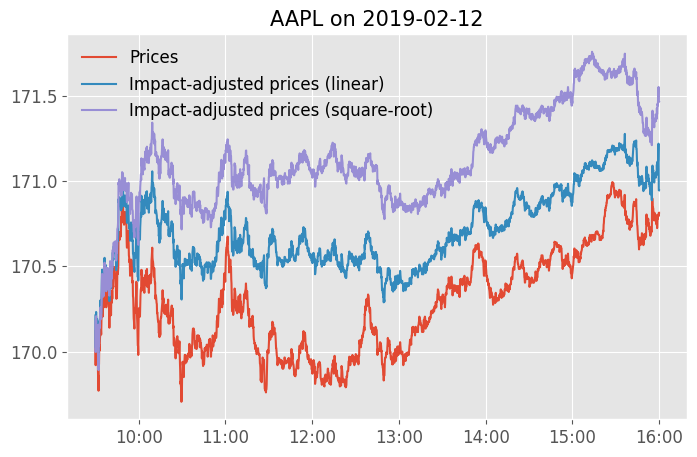

In [ ]:
times = pd.to_datetime(date) + pd.to_timedelta(prices.index)

fig = plt.figure(figsize=(8,5))
ax = plt.subplot(111)
ax.plot(times, prices.values, label="Prices")
ax.plot(times, adjusted_prices_linear.values, label="Impact-adjusted prices (linear)")
ax.plot(times, adjusted_prices_sqrt.values, label="Impact-adjusted prices (square-root)")
ax.legend(fontsize=12, frameon=False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.set_title(f"{stock} on {date}", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
plt.show()

In [ ]:
def twap_strategy(prices, ADV, total_volume_fraction, decay, impact_coef, kernel, price_vol):
    n_steps = len(prices)
    trade_volume = (total_volume_fraction * ADV) / n_steps
    twap_trades = pd.Series(np.full(n_steps, trade_volume), index=prices.index)
    impacted_prices = impact_resultant_prices(twap_trades, prices, decay, impact_coef, kernel, price_vol, ADV)
    trade_size_pct = (twap_trades / ADV) * 100
    impact = impacted_prices - prices
    cum_avg_buy = impacted_prices.expanding().mean()
    pnl1_pct = (impacted_prices / cum_avg_buy - 1) * 100
    pnl2_pct = (prices / cum_avg_buy - 1) * 100

    return impacted_prices, trade_size_pct, impact, pnl1_pct, pnl2_pct

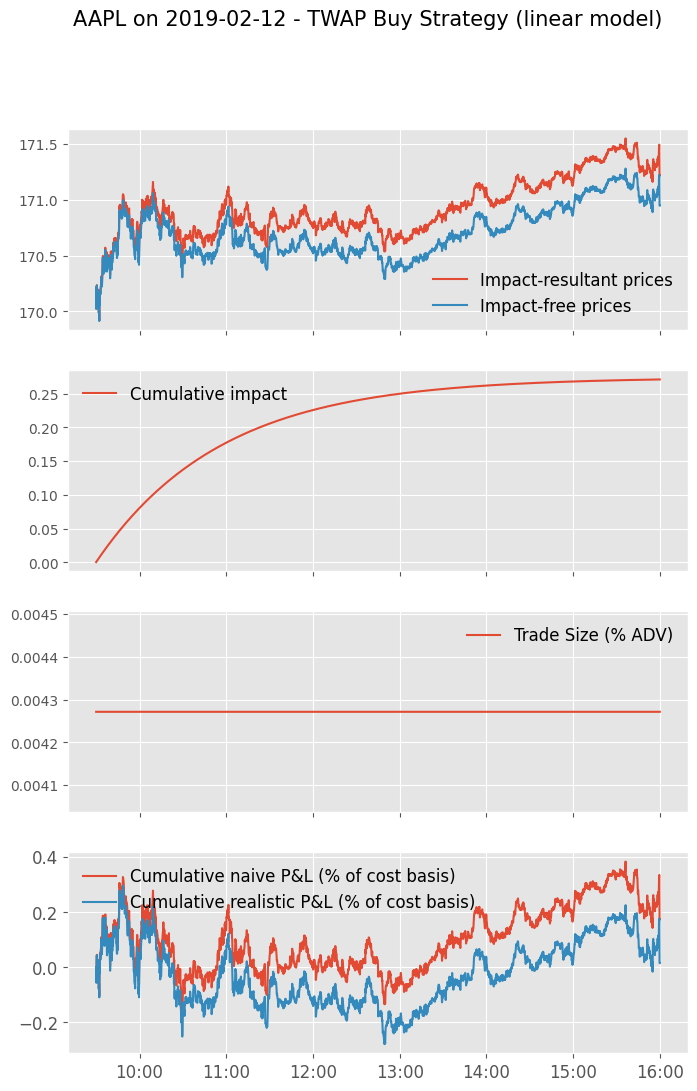

In [ ]:
impacted_prices_twap, trade_size_series, impact, pnl1_series, pnl2_series = twap_strategy(adjusted_prices_linear, ADV, 0.1, decay, linear_impact_coef, kernels["linear"], price_vol)

times = pd.to_datetime(date) + pd.to_timedelta(prices.index)
fig, axs = plt.subplots(4, 1, figsize=(8,12), sharex=True)
axs[0].plot(times, impacted_prices_twap.values, label="Impact-resultant prices")
axs[0].plot(times, adjusted_prices_linear.values, label="Impact-free prices")
axs[0].legend(fontsize=12, frameon=False)
axs[1].plot(times, impact.values, label="Cumulative impact")
axs[1].legend(fontsize=12, frameon=False)
axs[2].plot(times, trade_size_series.values, label="Trade Size (% ADV)")
axs[2].legend(fontsize=12, frameon=False)
axs[3].plot(times, pnl1_series.values, label="Cumulative naive P&L (% of cost basis)")
axs[3].plot(times, pnl2_series.values, label="Cumulative realistic P&L (% of cost basis)")
axs[3].legend(fontsize=12, frameon=False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.suptitle(f"{stock} on {date} - TWAP Buy Strategy (linear model)", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
plt.show()

In [ ]:
def vwap_strategy(prices, public_volume, ADV, total_volume_fraction, decay, impact_coef, kernel, price_vol):
    my_trades = total_volume_fraction * public_volume.abs()
    impacted_prices = impact_resultant_prices(my_trades, prices, decay, impact_coef, kernel, price_vol, ADV)
    trade_size_pct = (my_trades / ADV) * 100
    impact = impacted_prices - prices
    cum_avg_buy = impacted_prices.expanding().mean()
    pnl1_pct = (impacted_prices / cum_avg_buy - 1) * 100
    pnl2_pct = (prices / cum_avg_buy - 1) * 100

    return impacted_prices, trade_size_pct, impact, pnl1_pct, pnl2_pct

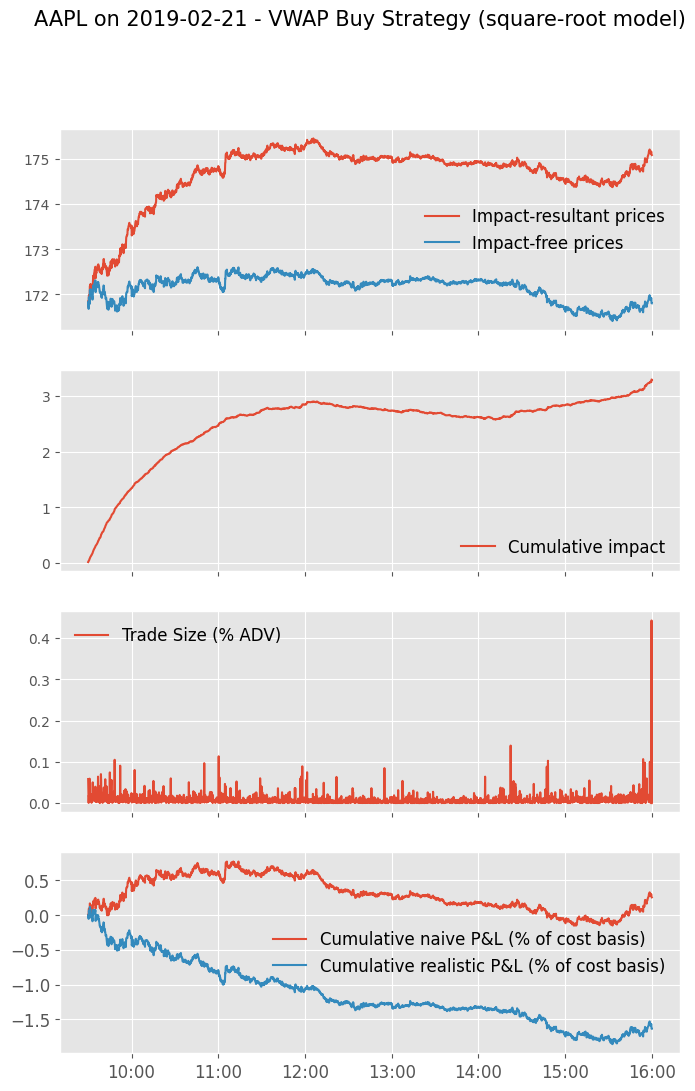

In [ ]:
vwap_impacted_prices, vwap_trade_size_pct, vwap_impact, vwap_pnl1_pct, vwap_pnl2_pct  = vwap_strategy(adjusted_prices_sqrt, traded_volume_df.loc[stock, date], ADV, 0.2, decay, sqrt_impact_coef, kernels["sqrt"], price_vol)

times = pd.to_datetime(date) + pd.to_timedelta(prices.index)
fig, axs = plt.subplots(4, 1, figsize=(8,12), sharex=True)
axs[0].plot(times, vwap_impacted_prices.values, label="Impact-resultant prices")
axs[0].plot(times, adjusted_prices_sqrt.values, label="Impact-free prices")
axs[0].legend(fontsize=12, frameon=False)
axs[1].plot(times, vwap_impact.values, label="Cumulative impact")
axs[1].legend(fontsize=12, frameon=False)
axs[2].plot(times, vwap_trade_size_pct.values, label="Trade Size (% ADV)")
axs[2].legend(fontsize=12, frameon=False)
axs[3].plot(times, vwap_pnl1_pct.values, label="Cumulative naive P&L (% of cost basis)")
axs[3].plot(times, vwap_pnl2_pct.values, label="Cumulative realistic P&L (% of cost basis)")
axs[3].legend(fontsize=12, frameon=False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.suptitle(f"{stock} on {date} - VWAP Buy Strategy (square-root model)", fontsize=15)
xfmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(xfmt)
plt.show()